## Statistical Methods (Zaman Serilerinde İstatistiksel Yöntemler)

In [1]:
#
# Bir önceki dosyalarda Yumuşatma (Smoothing) yöntemlerini görmüştük. Şimdi ise istatistiksel
# algoritmalarla (ARIMA ve SARIMA) zaman serisi tahmini yapacağız.
# Bu modeller, serinin geçmişteki kendi değerlerini (AutoRegressive) ve aynı zamanda
# hareketli ortalama hatalarını (Moving Average) baz alarak karmaşık tahminlerde bulunabilen güçlü istatistiksel altyapıya sahiplerdir.

import itertools # Özellikle hiperparametre döngülerinde kombinasyonlar bulmak için kullanılır.
import warnings  # Komut satırındaki sinir bozucu kırmızı uyarı kalabalığını önler.
import matplotlib.pyplot as plt # Plotting / Görselleştirme
import numpy as np # Sayısal işlemler
import pandas as pd # Temel veri işleme aracı
import statsmodels.api as sm # Makine öğrenmesi harici, en baba İstatistiksel analiz paketi
from sklearn.metrics import mean_absolute_error # Tahminin hatasını mutlak değerde ("ne kadar birim saptım?") ölçer
from statsmodels.tsa.arima.model import ARIMA  # Not: statsmodels>=0.12 ile eski "arima_model" modülü kaldırıldığı için içe aktarma yolu güncellendi. # Trendi olan ama mevsimselliği OLMAYAN serilerdeki favorimiz
from statsmodels.tsa.seasonal import seasonal_decompose # Seriyi mevsimsellik, trend gibi alt dinamiklere ayıran parça.
import statsmodels.tsa.api as smt
from statsmodels.tsa.statespace.sarimax import SARIMAX  # Hem trend hem mevsimsellik (Seasonality) içeren serilerdeki baba modelimiz!

# Gözümüzü yormaması için deprecated warning tarzı uyarıları kapatıyoruz.
warnings.filterwarnings('ignore')

## Veri Seti (Dataset)

In [2]:
# Atmospheric CO2 from Continuous Air Samples at Mauna Loa Observatory, Hawaii, U.S.A.
# Period of Record: March 1958 - December 2001
# (Hawaii Mauna Loa Gözlemevinden elde edilmiş aylık Atmosferik CO2 salınımı verisi)

data = sm.datasets.co2.load_pandas() # Veri dizinden (statsmodels'ın içinden) çekilir.
y = data.data  # Verinin kalbine (Dataframe'ine) 'y' ismini atıyoruz.

# Veride günlük vb. gözlemler olabilir. Veriyi ayın başına (MS - Month Start) resample (yeniden örnekleme) yaparak 
# aylar bazında düzgün bir formata oturtuyoruz. Ortalama (mean) ile ayın özetini çıkarıyoruz.
y = y['co2'].resample('MS').mean() 

# Arada sensör hatasından vs. kayıp veri varsa backward fill (bfill - kendinden bir sonraki veriyi al geçmişe yapıştır) ile dolduruyoruz.
y = y.fillna(y.bfill())

# Her modelde olduğu gibi eğitimi neyle yapıp denemeyi neyle asacağımızı seçmek için Holdout yapıyoruz:
train = y[:'1997-12-01'] # 1997 sonuna kadar EĞİT (Train)
test = y['1998-01-01':]  # 1998'den donra test et!

## ARIMA(p, d, q): (Autoregressive Integrated Moving Average)

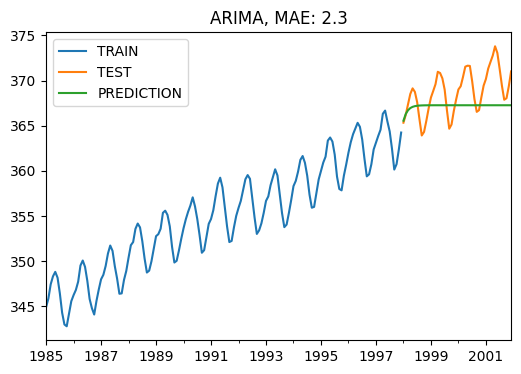

In [3]:
# ARIMA Modeli: Mevsimsellik İÇERMEYEN, trend barındıran zaman serilerini modellemek için inşa edilir.
# p: Gecikme sayısı (AutoRegressive parça - Kendi eski verimle ne kadar alakalıyım?)
# d: Fark alma (Integrated parça - Seriyi durağanlaştırmak için serinin kaç kere farkı alındı?)
# q: Hareketli Ortalama (Moving Average - Önceki zamanların hata terimlerini ne kadar modele dahil edelim?)

# (1,1,1) parametreleriyle "ezberden" bir arima modeli kurduk.
arima_model = ARIMA(train, order=(1, 1, 1)).fit()  # Not: yeni statsmodels API'sinde disp parametresi kaldırıldı. # disp=0 ekranda bilgi gürültüsü çıkarmasını engeller.

# Model kuruldu, peki içeriğindeki istatistikler geçerli mi, katsayıların (P>|z|) değerleri anlamlı mı?
arima_model.summary()

# 48 birimlik (48 Ay = 4 Yıl) geleceğe projeksiyon yapıp tahminleri "y_pred" e kaydettik. ([0] ifadesi değerleri matrix'ten sıyırmak için)
y_pred = arima_model.forecast(48)  # Not: yeni ARIMA API'sinde .forecast() dogrudan tahmin dizisini dondurur (eski API'de [0] gerekiyordu).
y_pred = pd.Series(y_pred, index=test.index) # Test setindeki indexleriyle (tarihlerle) eşleştirip zaman objesine çeviriyoruz.

# Grafiğe döküp hatalarını hesaplamak için küçük bir fonksiyon tanımlayalım:
def plot_co2(train, test, y_pred, title):
    mae = mean_absolute_error(test, y_pred) # Test verimizle modelin uydurduğu tahminler arasındaki açık "ortalama ne kadardır?"
    train["1985":].plot(legend=True, label="TRAIN", title=f"{title}, MAE: {round(mae,2)}") # Eğitim grafiği (sadece son kısımlar)
    test.plot(legend=True, label="TEST", figsize=(6, 4)) # Gerçekleşen Gelecek (Test)
    y_pred.plot(legend=True, label="PREDICTION")         # Bizim tahminimiz!
    plt.show()

# Ezbere verdiğimiz (1,1,1) değerleri bakalım nasıl bir grafik çizdi?
plot_co2(train, test, y_pred, "ARIMA")

## Hyperparameter Optimization (Model Parametrelerini(Derecelerini) Deneyerek Bulma)

p, d, ve q için 1,1,1 dedik ama belki 2,0,1 daha iyiydi?
Bunu denemek üzere permütasyon kombinasyonlar yapmamız gerekecek.

## AIC & BIC İstatistiklerine Göre Model Derecesini Belirleme

In [4]:
# AIC (Akaike Information Criterion): Bize kurulan modelin kompleksliğini ve başarısını harmanlar.
# AIC Puanı ne kadar DÜŞÜK olursa o kadar harikadır! Optimizasyondaki amacımız MAE(Hata) azaltmak yerine bu işin piri olan AIC'yi düşürmek!

p = d = q = range(0, 4) # p,d,q değerlerine 0'dan 3'e kadar denenecek rakamlar.
pdq = list(itertools.product(p, d, q)) # Sınırsız 3'lü kombinasyonlar listesi (0,0,0), (0,0,1) vs...


def arima_optimizer_aic(train, orders):
    # En iyi modelin AIC'sini rekor tutacağımız için sonsuzluktan (çok yüksek bir sayıdan) başlatalım. 
    best_aic, best_params = float("inf"), None
    
    # Oluşturduğumuz p,d,q kombinasyonlarını döngü içerisinde deniyoruz!
    for order in orders:
        try:
            arima_model_result = ARIMA(train, order).fit()  # Not: yeni statsmodels API'sinde disp parametresi kaldırıldı. # Kombinasyonlu modeli kur
            aic = arima_model_result.aic # Kurulan algoritmanın "Akaike Information Criterion" puanına bak
            
            # Bulduğum AIC bir öncekinden kısaysa ve iyiyse, rekorumu tazele:
            if aic < best_aic:
                best_aic, best_params = aic, order
            print('ARIMA%s AIC=%.2f' % (order, aic))
        except:
            # Uyumsuz, istatistiksel matematiği bozan parametreler olursa çökmesin yoksaysın diye Try-Except bloğu kullandık.
            continue
            
    print('Best ARIMA%s AIC=%.2f' % (best_params, best_aic)) # Şampiyonu açıkla!
    return best_params

# Parametrelerimizi AIC'ye göre optimize eden fonksiyonu başlattık.
best_params_aic = arima_optimizer_aic(train, pdq)

Best ARIMANone AIC=inf


## Final Model (SARIMA ÖNCESİ ARIMA'ya Son Bakış)

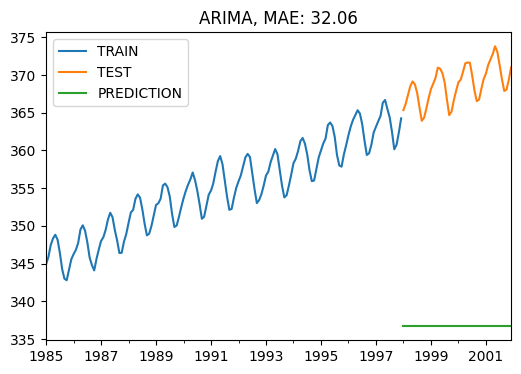

In [5]:
# İçerideki en iyi (p,d,q) değerlini fonksiyondan alıp modelimizi nihai olarak kuruyoruz.
arima_model = ARIMA(train, best_params_aic).fit()  # Not: yeni statsmodels API'sinde disp parametresi kaldırıldı.
y_pred = arima_model.forecast(48)  # Not: yeni ARIMA API'sinde .forecast() dogrudan tahmin dizisini dondurur (eski API'de [0] gerekiyordu). # Tahmin aldık.

# Grafikteki saatlerini test'e oturtuyoruz.
y_pred = pd.Series(y_pred, index=test.index)

# Çok daha iyi bir AIC ile tahminin nasıl evrildiğini görebiliriz.
plot_co2(train, test, y_pred, "ARIMA")

## SARIMA(p, d, q,  P,D,Q,M): (Seasonal Autoregressive Integrated Moving-Average)

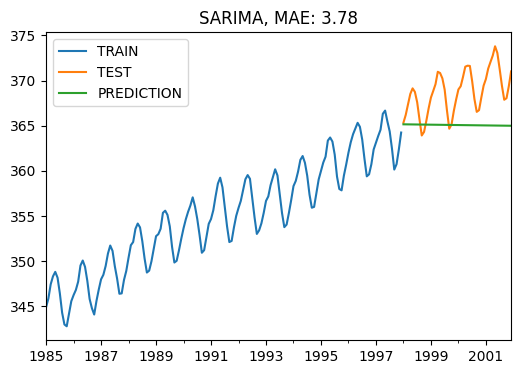

In [6]:
# ARIMA mevsimselliği algılayamazdı ve sonuçlar dümdüz çizgiler olarak gelirdi hatırlıyorsanız.
# Çünkü veride bahar aylarında azalan, kış aylarında artan zikzaklar (Mevsimsellik) bariz bellidir!
# SARIMA, ARIMA'nın büyük abisidir. (p,d,q) yapısına ek olarak mevsimsellik için ektra (P,D,Q,m) parametreleri içerir!
# "m" değeri (periyot), veri aylık olduğu için 12 girilecektir!

# SARIMAX kullanılıyor, burada X dışsal(Exogenous) etken demektir ama biz dış etken girmeden standart parametrelerle (1,0,1 ve 0,0,0,12) deneme gerçekleştiriyoruz.
model = SARIMAX(train, order=(1, 0, 1), seasonal_order=(0, 0, 0, 12))

sarima_model = model.fit()  # Not: yeni statsmodels API'sinde disp parametresi kaldırıldı. # Eğitimi atıyoruz.

y_pred_test = sarima_model.get_forecast(steps=48) # Modele "48 Adım Git" talimatı veriyoruz

y_pred = y_pred_test.predicted_mean # Matris kalabalığından sadece tahmin array'ini (.predicted_mean objesinden) alıyoruz.

y_pred = pd.Series(y_pred, index=test.index) # Yine indexleri testin aylarına çekerek eşliyoruz.

plot_co2(train, test, y_pred, "SARIMA") # Çizim yaptığımızda bir miktar da olsa dalgalanmayı kavradığını tespit edebileceğiz.

## Hyperparameter Optimization (SARIMA İçin Doğru Eğimi/Mevsimselliği Ölçme)

In [7]:
# p,d,q parametreleri (Normal Trend Değerleri) 0'dan 1'e deneme (çok yormamak için range ufak tutuldu)
p = d = q = range(0, 2)
pdq = list(itertools.product(p, d, q))

# BURASI ÖNEMLİ: seasonal_pdq dediğimiz yer Mevsimsel p,d,q katsayısını ve M periyodunu (Aylık olduğu için = 12) belirler!
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]


def sarima_optimizer_aic(train, pdq, seasonal_pdq):
    best_aic, best_order, best_seasonal_order = float("inf"), None, None
    for param in pdq: # Trend parametrelerini dön...
        for param_seasonal in seasonal_pdq: # Mevsimsellik parametrelerini dön...
            try:
                # Seçili iki kombinasyon setiyle SARIMA'yı inşaa et!
                sarimax_model = SARIMAX(train, order=param, seasonal_order=param_seasonal)
                results = sarimax_model.fit()  # Not: yeni statsmodels API'sinde disp parametresi kaldırıldı.
                aic = results.aic # Yeniden başarı metriği olarak o güzel istatistiksel AIC score üzerinden değerlendirmeye aldık.
                
                # Eğer daha düşük AIC varsa hemen kaydet!
                if aic < best_aic:
                    best_aic, best_order, best_seasonal_order = aic, param, param_seasonal
                print('SARIMA{}x{}12 - AIC:{}'.format(param, param_seasonal, aic))
            except:
                # İleri matematik hataları dönüp çökerse atla.
                continue
                
    print('SARIMA{}x{}12 - AIC:{}'.format(best_order, best_seasonal_order, best_aic))
    return best_order, best_seasonal_order

# Fonksiyonla en güzel modeli ve sezonluk order değerini belirledik!
best_order, best_seasonal_order = sarima_optimizer_aic(train, pdq, seasonal_pdq)

SARIMA(0, 0, 0)x(0, 0, 0, 12)12 - AIC:6922.606550808509
SARIMA(0, 0, 0)x(0, 0, 1, 12)12 - AIC:6318.305219680023


SARIMA(0, 0, 0)x(0, 1, 0, 12)12 - AIC:1643.9996657880379
SARIMA(0, 0, 0)x(0, 1, 1, 12)12 - AIC:1428.293892536191


SARIMA(0, 0, 0)x(1, 0, 0, 12)12 - AIC:1863.39596356044


SARIMA(0, 0, 0)x(1, 0, 1, 12)12 - AIC:1689.40813011729
SARIMA(0, 0, 0)x(1, 1, 0, 12)12 - AIC:1205.0254009707892


SARIMA(0, 0, 0)x(1, 1, 1, 12)12 - AIC:973.2077281535375
SARIMA(0, 0, 1)x(0, 0, 0, 12)12 - AIC:6269.190364744001


...

SARIMA(1, 1, 1)x(0, 1, 1, 12)12 - AIC:323.3128807083734


SARIMA(1, 1, 1)x(1, 0, 0, 12)12 - AIC:560.3099484676362


SARIMA(1, 1, 1)x(1, 0, 1, 12)12 - AIC:367.0926794976998


SARIMA(1, 1, 1)x(1, 1, 0, 12)12 - AIC:442.4874504643341


SARIMA(1, 1, 1)x(1, 1, 1, 12)12 - AIC:324.99646823263873
SARIMA(1, 1, 1)x(0, 1, 1, 12)12 - AIC:323.3128807083734


## Final Model (Makinenin Seçtiği Kaliteyle Tahmin Oluşturma)

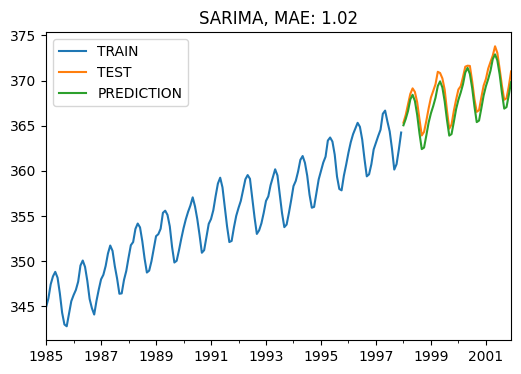

In [8]:
model = SARIMAX(train, order=best_order, seasonal_order=best_seasonal_order)
sarima_final_model = model.fit()  # Not: yeni statsmodels API'sinde disp parametresi kaldırıldı.

y_pred_test = sarima_final_model.get_forecast(steps=48)

y_pred = y_pred_test.predicted_mean
y_pred = pd.Series(y_pred, index=test.index)

# Grafikteki muazzam dalgalanma uyumunu ve MAE(Hata) değerindeki düşüşü fark edeceksiniz. Tam bir başyapıt!
plot_co2(train, test, y_pred, "SARIMA")

## BONUS: AIC YERİNE "MAE (Ortalama Mutlak Hata)" ile SARIMA Optimizasyonu

SARIMA(0, 0, 0)x(0, 0, 0, 12)12 - MAE:368.7634375
SARIMA(0, 0, 0)x(0, 0, 1, 12)12 - MAE:324.1790915673983
SARIMA(0, 0, 0)x(0, 1, 0, 12)12 - MAE:5.063020833333329


SARIMA(0, 0, 0)x(0, 1, 1, 12)12 - MAE:4.8033243706671405


SARIMA(0, 0, 0)x(1, 0, 0, 12)12 - MAE:5.117229146329808


SARIMA(0, 0, 0)x(1, 0, 1, 12)12 - MAE:4.93158664725405
SARIMA(0, 0, 0)x(1, 1, 0, 12)12 - MAE:3.323724885904871


SARIMA(0, 0, 0)x(1, 1, 1, 12)12 - MAE:1.5279900148707917
SARIMA(0, 0, 1)x(0, 0, 0, 12)12 - MAE:364.91786914276776


...

SARIMA(1, 1, 1)x(0, 1, 1, 12)12 - MAE:1.024473417529535


SARIMA(1, 1, 1)x(1, 0, 0, 12)12 - MAE:1.8003884742973792


SARIMA(1, 1, 1)x(1, 0, 1, 12)12 - MAE:1.0543569044805896


SARIMA(1, 1, 1)x(1, 1, 0, 12)12 - MAE:1.0362550103225832


SARIMA(1, 1, 1)x(1, 1, 1, 12)12 - MAE:1.0378883384220572
SARIMA(0, 1, 0)x(1, 1, 0, 12)12 - MAE:0.5343591417181486


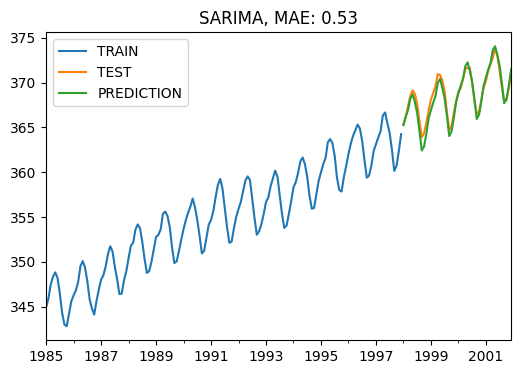

In [9]:
# Biz istatistikçiler gibi davrandık ve AIC değerini düşürmeyi baz aldık ancak bazen saf 
# "Modelin hata payı (MAE)'ye göre en iyisini bul" metodu da tercih edilebilir.

p = d = q = range(0, 2)
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]


def sarima_optimizer_mae(train, pdq, seasonal_pdq):
    best_mae, best_order, best_seasonal_order = float("inf"), None, None
    for param in pdq:
        for param_seasonal in seasonal_pdq:
            try:
                # Bu sefer model kurduğumuzda, .aic demek yerine modele forecast yaptırıp GERÇEK(TEST) veriyle kıyaslayacağız!
                model = SARIMAX(train, order=param, seasonal_order=param_seasonal)
                sarima_model = model.fit()  # Not: yeni statsmodels API'sinde disp parametresi kaldırıldı.
                y_pred_test = sarima_model.get_forecast(steps=48) # AIC'de test verisine gerek yoktu ama MAE hesabında tahmine muhtacız!
                y_pred = y_pred_test.predicted_mean
                
                mae = mean_absolute_error(test, y_pred) # MAE HESABI
                
                # Eğer AIC yerine daha düşük MAE (Hata Puanı) yakaladıysak kaydediyoruz:
                if mae < best_mae:
                    best_mae, best_order, best_seasonal_order = mae, param, param_seasonal
                print('SARIMA{}x{}12 - MAE:{}'.format(param, param_seasonal, mae))
            except:
                continue
    print('SARIMA{}x{}12 - MAE:{}'.format(best_order, best_seasonal_order, best_mae))
    return best_order, best_seasonal_order

# MAE'ye göre optimize edip sonuçları çekiyoruz:
best_order, best_seasonal_order = sarima_optimizer_mae(train, pdq, seasonal_pdq)

model = SARIMAX(train, order=best_order, seasonal_order=best_seasonal_order)
sarima_final_model = model.fit()  # Not: yeni statsmodels API'sinde disp parametresi kaldırıldı.

y_pred_test = sarima_final_model.get_forecast(steps=48)
y_pred = y_pred_test.predicted_mean
y_pred = pd.Series(y_pred, index=test.index)

plot_co2(train, test, y_pred, "SARIMA") # AIC Optimizasyonuyla benzer sonuçları verebilir, duruma ve veri setine göre farklılık arzedebilir tabi.

## Final Model (PROD - Canlı Ortama Çıkacak Gelecek Modeli)

In [10]:
# Modelimiz artık olgunlaştı. En son kullanıcının gördüğü değerleri de dahil edip modelimize HER ŞEYİ öğretiyoruz (Train set yerine tüm datayı(y) verdik)!

model = SARIMAX(y, order=best_order, seasonal_order=best_seasonal_order)
sarima_final_model = model.fit()  # Not: yeni statsmodels API'sinde disp parametresi kaldırıldı.

# Elimizde referans alınacak test vs kalmadığı için model tamamen gelecekteki 6 aya forecast edecek. Bunu dışarı çıkartıp müşteriye sunarız.
feature_predict = sarima_final_model.get_forecast(steps=6)
feature_predict = feature_predict.predicted_mean